# Principal Component Analysis (PCA) analysis on treasury yield curve

### 1. Imports
Imports the necessary libraries.

### 2. Data Loading & Preprocessing
Data processing daily treasury yield curve rates from a CSV (`daily-treasury-rates.csv`).

### 3. Rolling PCA Implementation
Performs PCA analysis on treasury yield curve
- Normalize data by calculating daily yield changes.
- Apply Principal Component Analysis (PCA) on rolling basis and incorporate window and exponential decay weight.
- Identifies and standardizes the first 3 principal components as **Level, Slope, and Curvature**.
- Projects the out-of-sample scores and returns structured DataFrames for loadings, scores, and explained variance.

### 4. PnL Attribution analysis from PCA
Performs PnL Attribution analysis on the impact of Level, Slope and Curvature given a set of random fixed-income portfolios.

### 5. VaR analysis from PCA
Evaluates Value at Risk (VaR) from Level, Slope and Curvature factors given a set of random fixed-income portfolios.

### 6. Hypertunning PCA performance
Performs grid search on finding the best rolling PCA window and decay factor that stablies factor loadings over time.


In [22]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import display
import itertools

In [23]:
def process_treasury_data(file_path="daily-treasury-rates.csv"):
    """Loads and standardizes treasury rate data, returning a DataFrame."""
    def std_col(col):
        if col.strip().lower() == "date": return "Date"
        mo = re.match(r"^\s*([\d.]+)\s*(?:Mo(?:nth)?|M)\s*$", col, re.IGNORECASE)
        if mo: return f"{mo.group(1)}M"
        yr = re.match(r"^\s*([\d.]+)\s*(?:Yr(?:s|ear)?|Y)\s*$", col, re.IGNORECASE)
        if yr: return f"{yr.group(1)}Y"
        return col.strip()
    df = pd.read_csv(file_path, parse_dates=["Date"]).rename(columns=std_col)
    df = df.set_index("Date").sort_index()
    return df
    
df = process_treasury_data()
df.head()


# df_pct = df.diff().dropna(how='all')
# df_pct.head()

,1M,1.5M,2M,3M,4M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,,,,
2010-01-04,0.05,NaN,NaN,0.08,NaN,0.18,0.45,1.09,1.66,2.65,3.36,3.85,4.60,4.65
2010-01-05,0.03,NaN,NaN,0.07,NaN,0.17,0.41,1.01,1.57,2.56,3.28,3.77,4.54,4.59
2010-01-06,0.03,NaN,NaN,0.06,NaN,0.15,0.40,1.01,1.60,2.60,3.33,3.85,4.63,4.70
2010-01-07,0.02,NaN,NaN,0.05,NaN,0.16,0.40,1.03,1.62,2.62,3.33,3.85,4.62,4.69
2010-01-08,0.02,NaN,NaN,0.05,NaN,0.15,0.37,0.96,1.56,2.57,3.31,3.83,4.61,4.70


In [24]:
# from sklearn import preprocessing
def apply_rolling_pca(df, tenors=None, window=252, decay=0.99):
    if tenors is None:
        tenors = ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y']
        
    # Get daily changes and drop rows with missing data for complete tensor alignment
    daily_changes = df[tenors].diff().dropna() * 100
    dates = daily_changes.index[window:]
    n_days = len(dates)
    n_tenors = len(tenors)
    
    # Pre-allocate numpy arrays for significant performance boost
    loadings = np.zeros((n_days, 3, n_tenors))
    scores = np.zeros((n_days, 3))
    explained_variance = np.zeros((n_days, 3))
    
    # Pre-calculate decay weights once
    weights = decay ** np.arange(window - 1, -1, -1)
    weights /= weights.sum()
    sqrt_weights = np.sqrt(weights)[:, None]
    
    # Extract underlying numpy array to bypass pandas indexing overhead in the loop
    data_vals = daily_changes.values
    pca = PCA(n_components=3)
    
    for idx in range(n_days):
        i = idx + window
        # Get window data and apply weights, shape: (window, n_tenors)
        window_data = data_vals[i-window:i]
        pca.fit(window_data * sqrt_weights)
        
        raw_pcs = pca.components_[:3].copy()

        # Re-assign back strictly ordered as [Level, Slope, Curvature]
        pc_level = max(raw_pcs, key=lambda x: abs(x.mean()))
        pc_slope = max([p for p in raw_pcs if not np.array_equal(p, pc_level)], key=lambda x: abs(x[-1] - x[0]))
        pc_curve = next(p for p in raw_pcs if not np.array_equal(p, pc_level) and not np.array_equal(p, pc_slope))
        
        pcs = np.array([pc_level, pc_slope, pc_curve])
        
        standard = 0 # switch
        if standard:
            # Standardize signs (Level mostly positive, Slope rising, Curvature bowing)
            if pcs[0].mean() < 0: pcs[0] *= -1
            if pcs[1, -1] < pcs[1, 0]: pcs[1] *= -1
            if pcs[2, n_tenors//2] > 0: pcs[2] *= -1
        else:
            # Alternatively, instead of static heuristics, do Temporal Tracking
            if idx > 0:
                for j in range(3):
                    # If the angle between today's PC and yesterday's PC is greater than 90 degrees (negative dot product)
                    # It means the algorithm arbitrarily flipped the sign today. Flip it back!
                    if np.dot(pcs[j], loadings[idx-1, j]) < 0:
                        pcs[j] *= -1
            
        loadings[idx] = pcs
        
        # Out-of-sample projection using dot product
        raw_dy_today = data_vals[i]
        scores[idx] = raw_dy_today @ pcs.T
        explained_variance[idx] = pca.explained_variance_ratio_
        
    # Return structured DataFrames cleanly
    pc1_df = pd.DataFrame(loadings[:, 0, :], index=dates, columns=tenors)
    pc2_df = pd.DataFrame(loadings[:, 1, :], index=dates, columns=tenors)
    pc3_df = pd.DataFrame(loadings[:, 2, :], index=dates, columns=tenors)
    
    scores_df = pd.DataFrame(scores, index=dates, columns=['PC1', 'PC2', 'PC3'])
    exp_var_df = pd.DataFrame(explained_variance, index=dates, columns=['PC1', 'PC2', 'PC3'])
    
    return pc1_df, pc2_df, pc3_df, scores_df, exp_var_df

level = 95
optimized = 0 # switch
if optimized:
    window = 252
    decay = 0.94
else:
    window = 252*3
    decay = 0.99



# Retrieve nicely structured outputs
pc1_loadings_df, pc2_loadings_df, pc3_loadings_df, scores_df, exp_var_df = apply_rolling_pca(df, window=window, decay=decay)

# PCA Checks
exp_var_df['Total'] = exp_var_df[['PC1', 'PC2', 'PC3']].sum(axis=1)
passed_series = exp_var_df['Total'] >= (level / 100)
print(f"Passed Ratio: {passed_series.mean():.2%} for {level}% info on a rolling {window}-day basis.")
exp_var_df.head()


Passed Ratio: 60.96% for 95% info on a rolling 756-day basis.


,PC1,PC2,PC3,Total
Date,,,,
2013-01-11,0.859745,0.059560,0.034195,0.953500
2013-01-14,0.859844,0.059401,0.034270,0.953515
2013-01-15,0.859555,0.059388,0.034529,0.953472
2013-01-16,0.859769,0.059133,0.034627,0.953529
2013-01-17,0.859508,0.059102,0.034723,0.953333


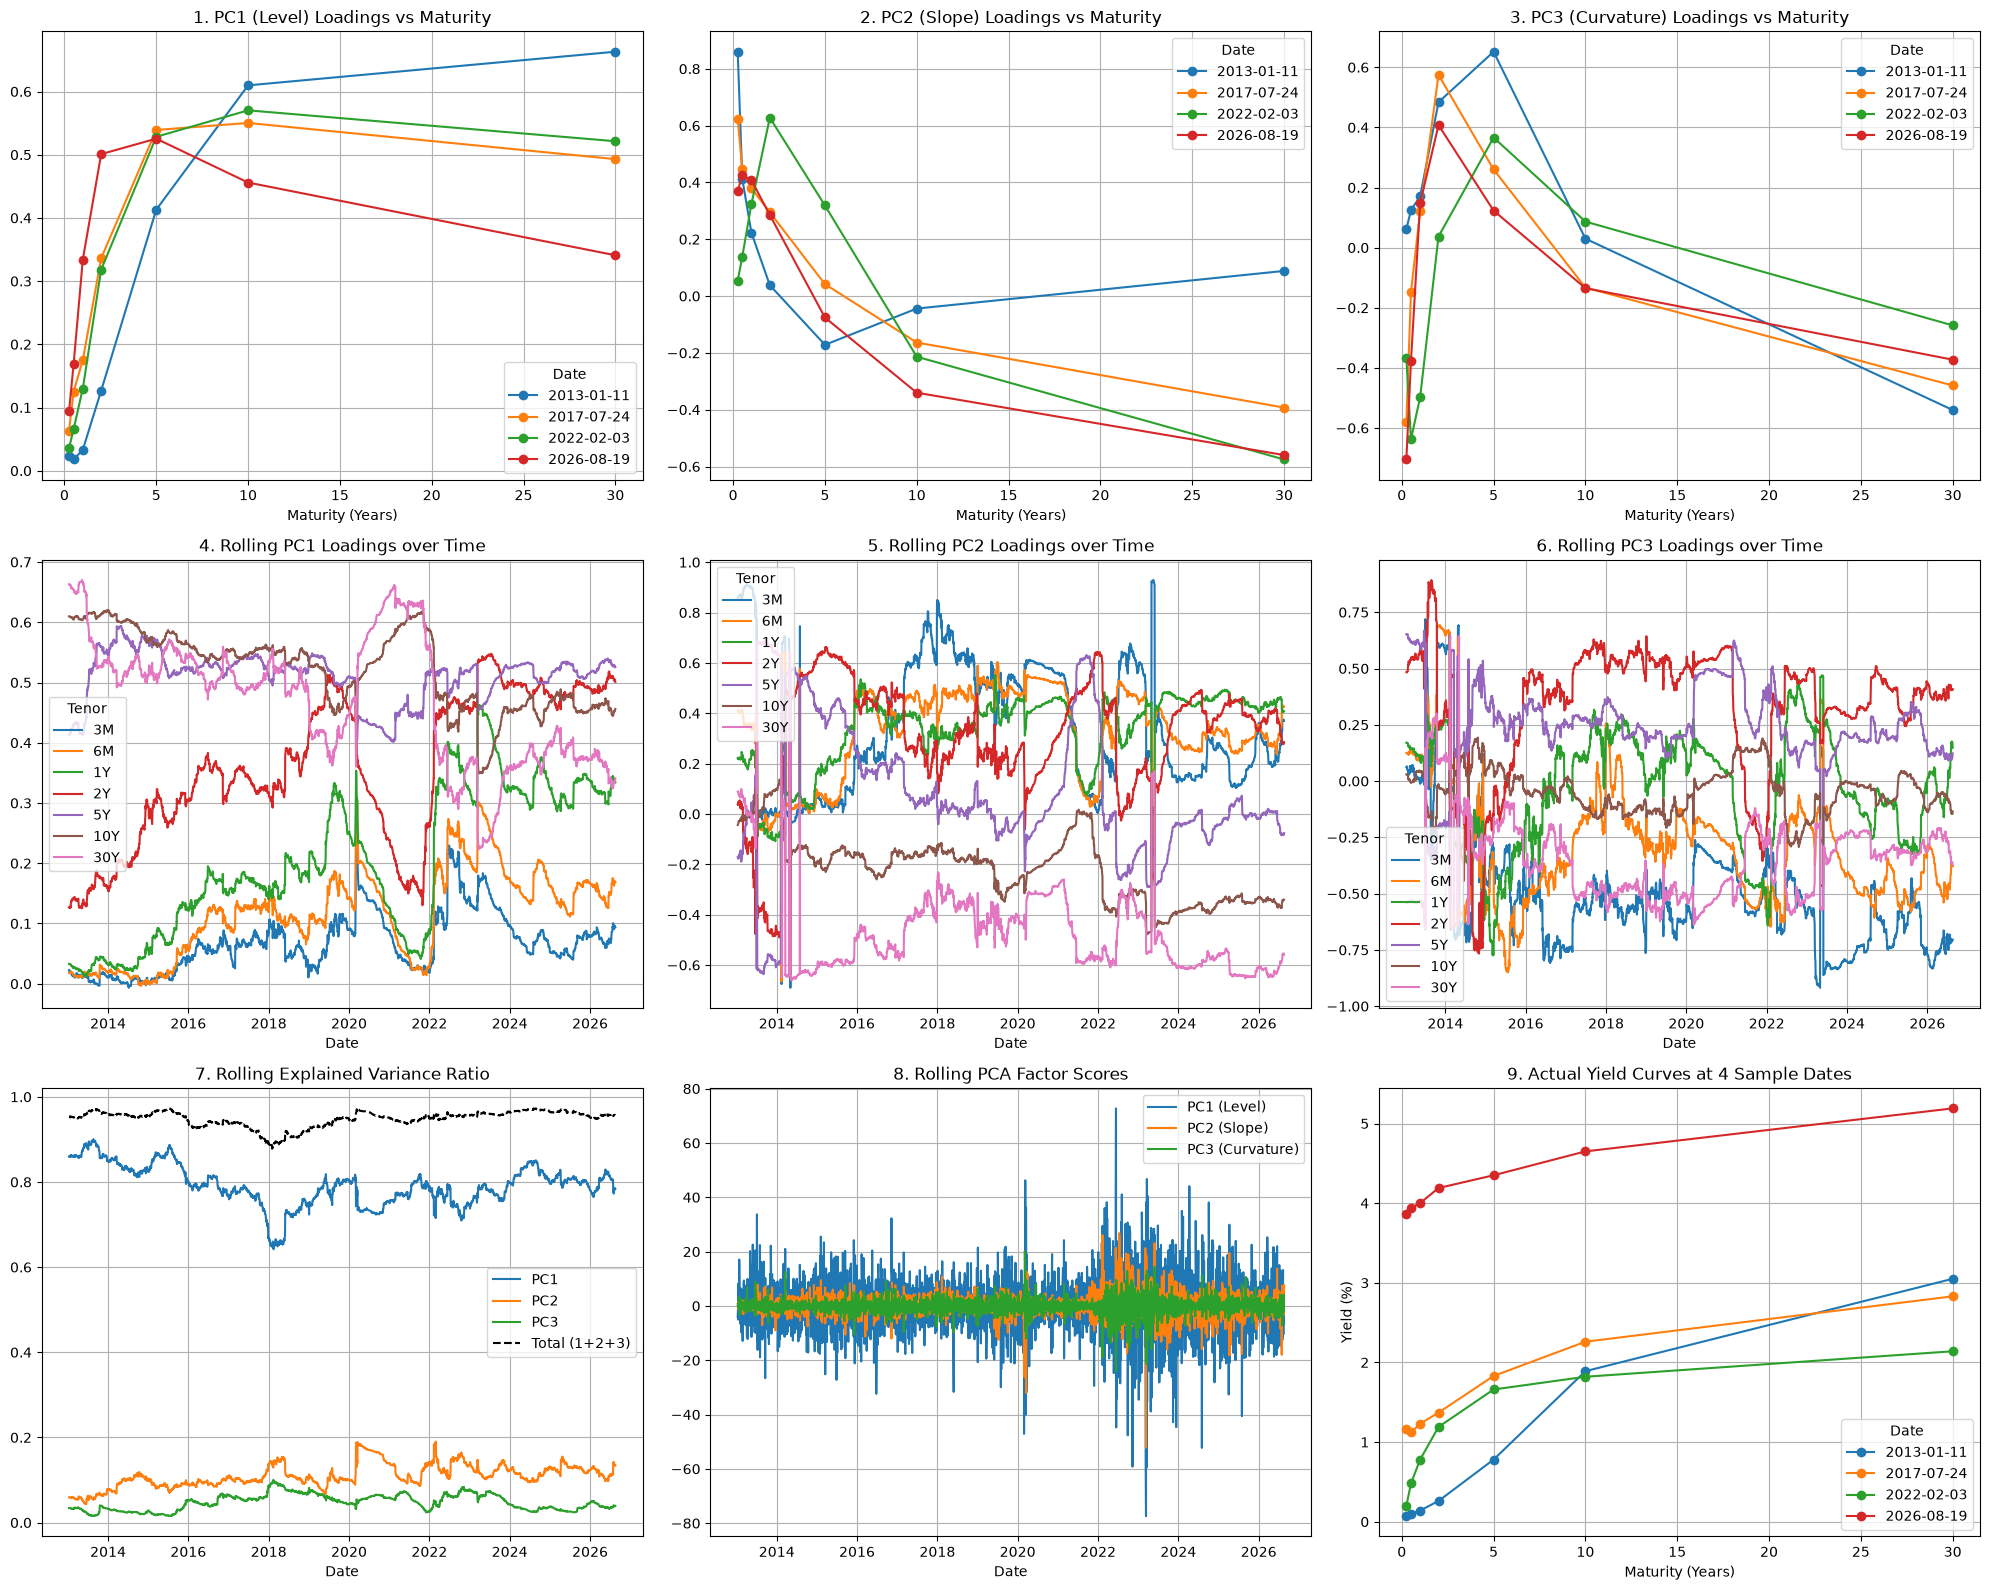

In [25]:
tenors = ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '30Y']

def tenor_to_years(col):
    if col.endswith('M'): return float(col[:-1]) / 12
    elif col.endswith('Y'): return float(col[:-1])
    return None

numeric_tenors = [tenor_to_years(t) for t in tenors]
dates = exp_var_df.index

# Elegantly pick 4 evenly spaced sample dates
if len(dates) >= 4:
    idx = np.linspace(0, len(dates) - 1, 4, dtype=int)
    sample_dates = dates[idx]
else:
    sample_dates = dates
fig, axs = plt.subplots(3, 3, figsize=(20, 16))
# Row 1: Loadings vs Maturity
for date in sample_dates:
    label = date.strftime('%Y-%m-%d')
    axs[0, 0].plot(numeric_tenors, pc1_loadings_df.loc[date], marker='o', label=label)
    axs[0, 1].plot(numeric_tenors, pc2_loadings_df.loc[date], marker='o', label=label)
    axs[0, 2].plot(numeric_tenors, pc3_loadings_df.loc[date], marker='o', label=label)
axs[0, 0].set_title("1. PC1 (Level) Loadings vs Maturity")
axs[0, 1].set_title("2. PC2 (Slope) Loadings vs Maturity")
axs[0, 2].set_title("3. PC3 (Curvature) Loadings vs Maturity")
for ax in axs[0, :]:
    ax.set_xlabel("Maturity (Years)")
    ax.legend(title="Date")
    ax.grid(True)
# Row 2: Rolling Loadings Stability
for t in tenors:
    axs[1, 0].plot(pc1_loadings_df.index, pc1_loadings_df[t], label=t)
    axs[1, 1].plot(pc2_loadings_df.index, pc2_loadings_df[t], label=t)
    axs[1, 2].plot(pc3_loadings_df.index, pc3_loadings_df[t], label=t)
axs[1, 0].set_title("4. Rolling PC1 Loadings over Time")
axs[1, 1].set_title("5. Rolling PC2 Loadings over Time")
axs[1, 2].set_title("6. Rolling PC3 Loadings over Time")
for ax in axs[1, :]:
    ax.set_xlabel("Date")
    ax.legend(title="Tenor")
    ax.grid(True)
# Row 3: Explained Variance, Factor Scores, and Raw Yield Curves
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC1'], label='PC1')
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC2'], label='PC2')
axs[2, 0].plot(exp_var_df.index, exp_var_df['PC3'], label='PC3')
axs[2, 0].plot(exp_var_df.index, exp_var_df['Total'], label='Total (1+2+3)', color='black', linestyle='--')
axs[2, 0].set_title("7. Rolling Explained Variance Ratio")
axs[2, 0].set_xlabel("Date")
axs[2, 0].legend()
axs[2, 0].grid(True)
axs[2, 1].plot(scores_df.index, scores_df['PC1'], label='PC1 (Level)')
axs[2, 1].plot(scores_df.index, scores_df['PC2'], label='PC2 (Slope)')
axs[2, 1].plot(scores_df.index, scores_df['PC3'], label='PC3 (Curvature)')
axs[2, 1].set_title("8. Rolling PCA Factor Scores")
axs[2, 1].set_xlabel("Date")
axs[2, 1].legend()
axs[2, 1].grid(True)
for date in sample_dates:
    label = date.strftime('%Y-%m-%d')
    axs[2, 2].plot(numeric_tenors, df.loc[date, tenors], marker='o', label=label)
axs[2, 2].set_title("9. Actual Yield Curves at 4 Sample Dates")
axs[2, 2].set_xlabel("Maturity (Years)")
axs[2, 2].set_ylabel("Yield (%)")
axs[2, 2].legend(title="Date")
axs[2, 2].grid(True)
plt.tight_layout()
plt.show()


In [26]:
dv01_sets = {
    "1. Level (outright duration)": pd.Series(
        [200, 200, 200, 200, 200, 200, 200], index=tenors),
    "2. Slope (2s10s steepener)": pd.Series(
        [0, 0, 0, 1000, 0, -1000, 0], index=tenors),
    "3. Curvature (2s5s10s butterfly)": pd.Series(
        [0, 0, 0, 500, -1000, 500, 0], index=tenors),
    "4. Asymmetric multi-point butterfly": pd.Series(
        [0, 0, 1000, 0, 500, -800, -100], index=tenors),
    "5. High-frequency alternating (sawtooth)": pd.Series(
        [1000, -1000, 1000, -1000, 1000, -1000, 1000], index=tenors),
}

# Re-align daily changes with the days we ran the out-of-sample PCA on
daily_changes_bps = df[tenors].diff().dropna() * 100
daily_changes_bps = daily_changes_bps.loc[scores_df.index]

attribution_results = {}

for name, dv01 in dv01_sets.items():
    # Fully vectorized computation across the entire time series for factor sensitivities
    factor_dv01_pc1 = pc1_loadings_df.dot(dv01)
    factor_dv01_pc2 = pc2_loadings_df.dot(dv01)
    factor_dv01_pc3 = pc3_loadings_df.dot(dv01)
    
    # Fully vectorized PnL attribution
    pnl_attribution = pd.DataFrame({
        'PC1 (Level) PnL': -factor_dv01_pc1 * scores_df['PC1'],
        'PC2 (Slope) PnL': -factor_dv01_pc2 * scores_df['PC2'],
        'PC3 (Curvature) PnL': -factor_dv01_pc3 * scores_df['PC3'],
    }, index=scores_df.index).round(2)
    
    pnl_attribution['Total PCA PnL'] = pnl_attribution.sum(axis=1)
    
    # Validation: Actual PnL and unexplained Residual
    pnl_attribution['Actual PnL'] = -(daily_changes_bps @ dv01)
    pnl_attribution['Residual'] = pnl_attribution['Actual PnL'] - pnl_attribution['Total PCA PnL']
    
    attribution_results[name] = pnl_attribution
    
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    pnl_attribution = pnl_attribution.round(2)
    display(pnl_attribution.head()) # Use `display()` if running inside Jupyter for pretty tables



1. Level (outright duration)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,1513.53,-288.50,-62.63,1162.40,1200.0,37.60
2013-01-14,-14.96,-356.75,-37.29,-409.00,-400.0,9.00
2013-01-15,1898.68,-347.62,70.96,1622.02,1600.0,-22.02
2013-01-16,716.64,245.56,-82.08,880.12,800.0,-80.12
2013-01-17,-3107.41,345.85,-189.14,-2950.70,-3000.0,-49.30



2. Slope (2s10s steepener)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-1937.92,-84.30,-144.69,-2166.91,-2000.0,166.91
2013-01-14,19.17,-102.20,-85.82,-168.85,-0.0,168.85
2013-01-15,-2433.04,-95.50,162.92,-2365.62,-3000.0,-634.38
2013-01-16,-920.14,75.96,-188.98,-1033.16,-2000.0,-966.84
2013-01-17,3992.88,100.29,-437.82,3655.35,3000.0,-655.35



3. Curvature (2s5s10s butterfly)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-180.08,-173.02,125.87,-227.23,-1000.0,-772.77
2013-01-14,1.81,-222.15,74.45,-145.89,-0.0,145.89
2013-01-15,-229.22,-215.07,-141.29,-585.58,-1500.0,-914.42
2013-01-16,-88.99,158.61,164.96,234.58,1000.0,765.42
2013-01-17,382.46,226.33,382.67,991.46,500.0,-491.46



4. Asymmetric multi-point butterfly


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,-1261.50,-167.27,-167.87,-1596.64,-900.0,696.64
2013-01-14,12.47,-199.38,-99.50,-286.41,-0.0,286.41
2013-01-15,-1582.28,-190.60,188.93,-1583.95,-1200.0,383.95
2013-01-16,-596.99,132.69,-219.68,-683.98,-1700.0,-1016.02
2013-01-17,2591.85,181.35,-508.65,2264.55,2500.0,235.45



5. High-frequency alternating (sawtooth)


,PC1 (Level) PnL,PC2 (Slope) PnL,PC3 (Curvature) PnL,Total PCA PnL,Actual PnL,Residual
Date,,,,,,
2013-01-11,1515.08,-608.42,93.78,1000.44,2000.0,999.56
2013-01-14,-15.00,-746.24,55.57,-705.67,-0.0,705.67
2013-01-15,1903.73,-723.31,-105.29,1075.13,2000.0,924.87
2013-01-16,719.26,499.60,122.69,1341.55,0.0,-1341.55
2013-01-17,-3116.44,695.46,283.12,-2137.86,-1000.0,1137.86


In [27]:
# Pure N-day Historical VaR method (Empirical Rolling Sum - Vectorized)
N = 10

# 1. Pre-compute N-day rolling shocks for all 3 PCs simultaneously.
# Extract as a numpy array for maximum speed. Shape: (num_days, 3)
n_day_shocks = scores_df[['PC1', 'PC2', 'PC3']].rolling(window=N).sum().dropna().values

# 2. Extract today's latest loadings as a single (3, 7) matrix
loadings_today = np.array([
    pc1_loadings_df.iloc[-1],
    pc2_loadings_df.iloc[-1],
    pc3_loadings_df.iloc[-1]
])

print(f"--- 95% {N}-Day Pure Historical Component VaR ---")

# 3. Vectorized Portfolio Loop
for name, dv01 in dv01_sets.items():
    
    # A. Today's Factor DV01s (Matrix Multiplication)
    # Shape: (3, 7) matrix @ (7,) vector -> (3,) array [DV01_PC1, DV01_PC2, DV01_PC3]
    factor_dv01s_today = loadings_today @ dv01.values
    
    # B. Simulate historical PnL components (Numpy Broadcasting)
    # Shape: (num_days, 3) * (3,) -> (num_days, 3) 
    sim_pnl_components = -n_day_shocks * factor_dv01s_today
    
    # C. Calculate Total PnL (Sum across the 3 PCs for each simulated day)
    sim_total_pnl = sim_pnl_components.sum(axis=1)
    
    # D. Calculate N-Day VaR (5th percentile)
    # axis=0 computes the percentile for PC1, PC2, and PC3 all at once instantly
    var_95_components = np.percentile(sim_pnl_components, 5, axis=0) 
    var_95_total = np.percentile(sim_total_pnl, 5)
    
    # E. Print results
    print(f"\n{name}")
    print(f"Total VaR: ${abs(var_95_total):,.2f}")
    print(f"PC1: ${abs(var_95_components[0]):,.2f} | "
          f"PC2: ${abs(var_95_components[1]):,.2f} | "
          f"PC3: ${abs(var_95_components[2]):,.2f}")


--- 95% 10-Day Pure Historical Component VaR ---

1. Level (outright duration)
Total VaR: $26,437.25
PC1: $25,042.95 | PC2: $2,188.76 | PC3: $2,623.42

2. Slope (2s10s steepener)
Total VaR: $13,865.30
PC1: $2,327.30 | PC2: $13,340.02 | PC3: $6,598.04

3. Curvature (2s5s10s butterfly)
Total VaR: $2,408.87
PC1: $2,168.18 | PC2: $1,022.93 | PC3: $163.47

4. Asymmetric multi-point butterfly
Total VaR: $18,162.51
PC1: $10,240.55 | PC2: $14,893.21 | PC3: $4,305.44

5. High-frequency alternating (sawtooth)
Total VaR: $13,493.55
PC1: $8,720.01 | PC2: $4,366.67 | PC3: $10,088.77


In [28]:
def optimize_pca_params(df, windows=[60, 126, 252, 500], decays=[0.90, 0.95, 0.99, 1.0], expl_threshold=0.95):
    """
    Grid searches PCA parameters to find the best tradeoff between 
    explanatory power and loading stability.
    """
    print(f"Starting grid search over {len(windows) * len(decays)} combinations...")
    results = []
    
    # Iterate through all combinations of window and decay
    for w, d in itertools.product(windows, decays):
        
        # Run your existing fast PCA function
        pc1_df, pc2_df, pc3_df, scores_df, exp_var_df = apply_rolling_pca(df, window=w, decay=d)
        
        # 1. Metric: Explanatory Power
        exp_var_df['Total'] = exp_var_df[['PC1', 'PC2', 'PC3']].sum(axis=1)
        mean_expl_var = exp_var_df['Total'].mean()
        pass_ratio = (exp_var_df['Total'] >= expl_threshold).mean()
        
        # 2. Metric: Loading Instability (Lower is better)
        # We calculate the mean absolute daily change in the loadings for PC1 and PC2
        pc1_instability = pc1_df.diff().abs().mean().mean()
        pc2_instability = pc2_df.diff().abs().mean().mean()
        
        # A combined penalty score (scaled up by 1000 for easier readability)
        instability_score = (pc1_instability + pc2_instability) * 1000
        
        results.append({
            'Window': w,
            'Decay': d,
            'Mean Expl Var': round(mean_expl_var, 4),
            'Pass Ratio (>95%)': round(pass_ratio, 4),
            'Instability Penalty': round(instability_score, 4)
        })
        
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Rank the results: 
    # Best models have high explanatory power (Pass Ratio) AND low jitter (Instability)
    results_df = results_df.sort_values(
        by=['Pass Ratio (>95%)', 'Instability Penalty'], 
        ascending=[False, True]
    ).reset_index(drop=True)
    
    return results_df

test_windows = [60, 126, 1*252, 2*252, 3*252] 
test_decays = [0.94, 0.97, 0.99, 0.997, 1.0]

optimization_results = optimize_pca_params(df, windows=test_windows, decays=test_decays, expl_threshold=0.95)

print("\n--- Top 5 PCA Parameter Combinations ---")
display(optimization_results.head(5))


Starting grid search over 25 combinations...

--- Top 5 PCA Parameter Combinations ---


,Window,Decay,Mean Expl Var,Pass Ratio (>95%),Instability Penalty
0,60,0.94,0.9578,0.7399,60.4713
1,126,0.94,0.9572,0.7329,54.9758
2,252,0.94,0.9567,0.7263,53.8703
3,504,0.94,0.9555,0.7085,55.0941
4,60,0.97,0.9555,0.7079,33.9463
